<a href="https://colab.research.google.com/github/Muskanateeq/Deep-Learning-Computer-Vision-Projects/blob/main/Facial_Emotion_Recognition_(CNN)_%7C_FER2013.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ashishpatel26_facial_expression_recognitionferchallenge_path = kagglehub.dataset_download('ashishpatel26/facial-expression-recognitionferchallenge')

print('Data source import complete.')


# 🎭 Facial Expression Recognition using CNN (TensorFlow/Keras)
---
### Project Overview
This notebook implements a complete deep learning pipeline to classify facial expressions into 7 emotion categories using the FER2013 dataset. The pipeline covers:
- Data loading & exploration
- Preprocessing & augmentation
- CNN model building (custom + optional transfer learning)
- Training with callbacks
- Evaluation (accuracy, confusion matrix, classification report, ROC curve)
- Grad-CAM visualization
- Testing on external/personal images

In [ ]:
Collect Dataset
↓
Load Images
↓
Data Cleaning
↓
Image Preprocessing (Load Image, Resize , Convert to Tensor, Normalize, Ready for CNN)
↓
Data Augmentation
↓
Train / Validation / Test Split
↓
Create Dataset Class
↓
Create DataLoader
↓
Build CNN Model (Input Image, Convolution, Activation (ReLU), Pooling, Convolution, Activation, Pooling, Flatten, Fully Connected, Output)
↓
Loss Function
↓
Optimizer
↓
Training Loop
↓
Validation Loop
↓
Evaluation
↓
Hyperparameter Tuning
↓
Save Model
↓
Deployment

## Step 0: Install Required Libraries
> Run this cell once. On Kaggle, most libraries are pre-installed.

In [ ]:
# Install any missing libraries (run once on Kaggle)
# opencv-python is used for image processing
# grad-cam is used for Grad-CAM visualization
!pip install opencv-python-headless grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 74.3 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Step 1: Import Libraries

In [ ]:
# ─── Standard Library ───────────────────────────────────────────────────────
import os                          # For file/directory operations
import random                      # For reproducibility seeding
import warnings                    # To suppress unnecessary warnings
warnings.filterwarnings('ignore')  # Suppress all warnings for clean output

# ─── Numerical & Data Manipulation ──────────────────────────────────────────
import numpy as np                 # Fundamental array/math operations
import pandas as pd                # Data manipulation and analysis

# ─── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt    # Core plotting library
import matplotlib.cm as cm         # Colormap for Grad-CAM overlays
import seaborn as sns              # Statistical visualizations (heatmaps etc.)

# ─── Image Processing ───────────────────────────────────────────────────────
import cv2                         # OpenCV: image reading, resizing, processing
from PIL import Image              # PIL: alternative image I/O

# ─── Scikit-learn: Metrics & Utilities ──────────────────────────────────────
from sklearn.model_selection import train_test_split           # Dataset splitting
from sklearn.metrics import (classification_report,            # Per-class metrics
                              confusion_matrix,                 # Confusion matrix
                              roc_curve, auc,                   # ROC & AUC
                              ConfusionMatrixDisplay)           # Matrix display helper
from sklearn.preprocessing import label_binarize               # One-hot for ROC curve

# ─── TensorFlow / Keras ─────────────────────────────────────────────────────
import tensorflow as tf                                         # Deep learning framework
from tensorflow import keras                                    # High-level Keras API
from tensorflow.keras import layers, models, regularizers      # Core building blocks
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,                                         # Real-time data augmentation
    img_to_array, load_img)                                     # Image I/O helpers
from tensorflow.keras.callbacks import (EarlyStopping,         # Stop training when no improvement
                                         ModelCheckpoint,       # Save best model weights
                                         ReduceLROnPlateau)     # Reduce LR when plateau
from tensorflow.keras.utils import to_categorical              # One-hot encoding labels
from tensorflow.keras.applications import MobileNetV2          # Pre-trained model for transfer learning

# ─── Reproducibility ────────────────────────────────────────────────────────
SEED = 42                                   # Fixed random seed for reproducibility
np.random.seed(SEED)                        # Seed NumPy
random.seed(SEED)                           # Seed Python random
tf.random.set_seed(SEED)                    # Seed TensorFlow

print(f'✅ TensorFlow version: {tf.__version__}')   # Confirm TF is loaded
print(f'✅ Keras version: {keras.__version__}')      # Confirm Keras version
print(f'✅ GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')  # Check GPU

2026-06-16 11:49:45.524655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781610585.721538      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781610585.777342      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781610586.211979      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781610586.212027      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781610586.212029      57 computation_placer.cc:177] computation placer alr

✅ TensorFlow version: 2.19.0
✅ Keras version: 3.10.0
✅ GPU Available: True


## Step 2: Configuration & Constants

In [ ]:
# ─── Paths ───────────────────────────────────────────────────────────────────
# FER2013 on Kaggle is at /kaggle/input/fer2013/
# It contains a single CSV file: fer2013.csv
DATASET_PATH = '/kaggle/input/datasets/ashishpatel26/facial-expression-recognitionferchallenge/fer2013/fer2013/fer2013.csv'   # Path to FER2013 CSV on Kaggle
MODEL_SAVE_PATH = '/kaggle/working/best_model.keras'  # Path to save the best trained model

# ─── Image Settings ──────────────────────────────────────────────────────────
IMG_SIZE = 48            # FER2013 images are 48x48 pixels natively
IMG_SIZE_RGB = 48        # We'll convert grayscale to RGB (3 channels) later
NUM_CHANNELS = 3         # RGB channels (grayscale repeated 3x for pre-trained models)
NUM_CLASSES = 7          # 7 emotions in FER2013

# ─── Training Hyperparameters ─────────────────────────────────────────────────
BATCH_SIZE = 64          # Number of samples per gradient update
EPOCHS = 50            # Maximum training epochs (EarlyStopping will stop earlier)
LEARNING_RATE = 1e-3     # Initial learning rate for Adam optimizer
VAL_SPLIT = 0.2          # 20% of training data used for validation
TEST_SPLIT = 0.1         # 10% of total data held out as test set

# ─── Emotion Labels ──────────────────────────────────────────────────────────
# FER2013 maps integer labels 0-6 to these emotions
EMOTION_LABELS = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}
CLASS_NAMES = list(EMOTION_LABELS.values())   # List of class names for plotting

# ─── Plotting Style ───────────────────────────────────────────────────────────
sns.set_style('whitegrid')          # Seaborn white grid theme
plt.rcParams['figure.dpi'] = 100    # Set figure DPI for better resolution

print('✅ Configuration set successfully!')
print(f'   Image size  : {IMG_SIZE}x{IMG_SIZE}x{NUM_CHANNELS}')
print(f'   Classes     : {NUM_CLASSES} → {CLASS_NAMES}')
print(f'   Batch size  : {BATCH_SIZE}')
print(f'   Max epochs  : {EPOCHS}')

✅ Configuration set successfully!
   Image size  : 48x48x3
   Classes     : 7 → ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
   Batch size  : 64
   Max epochs  : 50


## Step 3: Load Dataset (FER2013 CSV)

In [ ]:
# ─── Load the CSV file ────────────────────────────────────────────────────────
# FER2013 CSV has 3 columns: 'emotion', 'pixels', 'Usage'
# 'emotion'  → integer label 0-6
# 'pixels'   → space-separated string of 2304 pixel values (48x48)
# 'Usage'    → 'Training', 'PublicTest', 'PrivateTest'
df = pd.read_csv(DATASET_PATH)    # Load entire CSV into a pandas DataFrame

print('✅ Dataset loaded successfully!')
print(f'   Total samples : {len(df):,}')          # Total rows in dataset
print(f'   Columns       : {list(df.columns)}')   # Column names
print()
df.head()    # Show first 5 rows to inspect structure

✅ Dataset loaded successfully!
   Total samples : 35,887
   Columns       : ['emotion', 'pixels', 'Usage']



,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


## Step 4: Dataset Exploration (EDA)

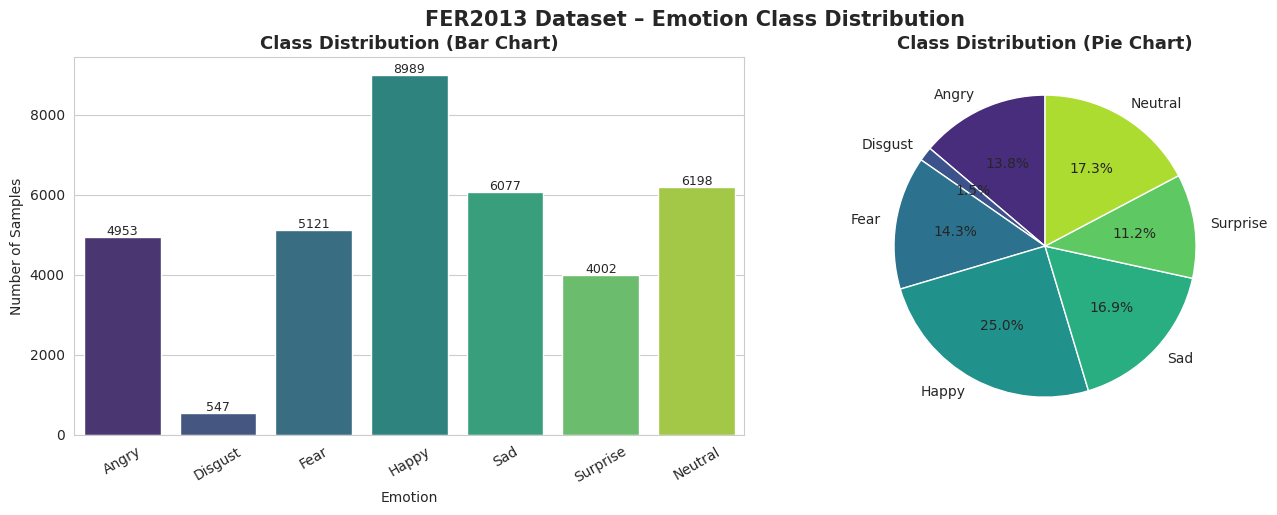

⚠️  Note: The dataset is imbalanced — "Disgust" is significantly under-represented.


In [ ]:
# ─── Class Distribution ───────────────────────────────────────────────────────
# Count how many samples exist per emotion class
class_counts = df['emotion'].value_counts().sort_index()   # Count per class, sorted by label
class_counts.index = [EMOTION_LABELS[i] for i in class_counts.index]  # Replace int index with names

fig, axes = plt.subplots(1, 2, figsize=(14, 5))   # Create a figure with 2 subplots

# ── Bar Chart ──
sns.barplot(x=class_counts.index,         # Emotion names on x-axis
            y=class_counts.values,         # Counts on y-axis
            palette='viridis',             # Color palette
            ax=axes[0])                    # Plot in first subplot
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Emotion')             # Label x-axis
axes[0].set_ylabel('Number of Samples')   # Label y-axis
axes[0].tick_params(axis='x', rotation=30)  # Rotate x labels for readability
# Add count labels on top of each bar
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)

# ── Pie Chart ──
axes[1].pie(class_counts.values,           # Slice sizes
            labels=class_counts.index,     # Slice labels
            autopct='%1.1f%%',             # Show percentage on each slice
            startangle=90,                 # Start from top
            colors=sns.color_palette('viridis', 7))  # Same palette
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()   # Adjust layout to prevent overlap
plt.suptitle('FER2013 Dataset – Emotion Class Distribution', y=1.02, fontsize=15, fontweight='bold')
plt.savefig('/kaggle/working/class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()           # Display the figure
print('⚠️  Note: The dataset is imbalanced — "Disgust" is significantly under-represented.')

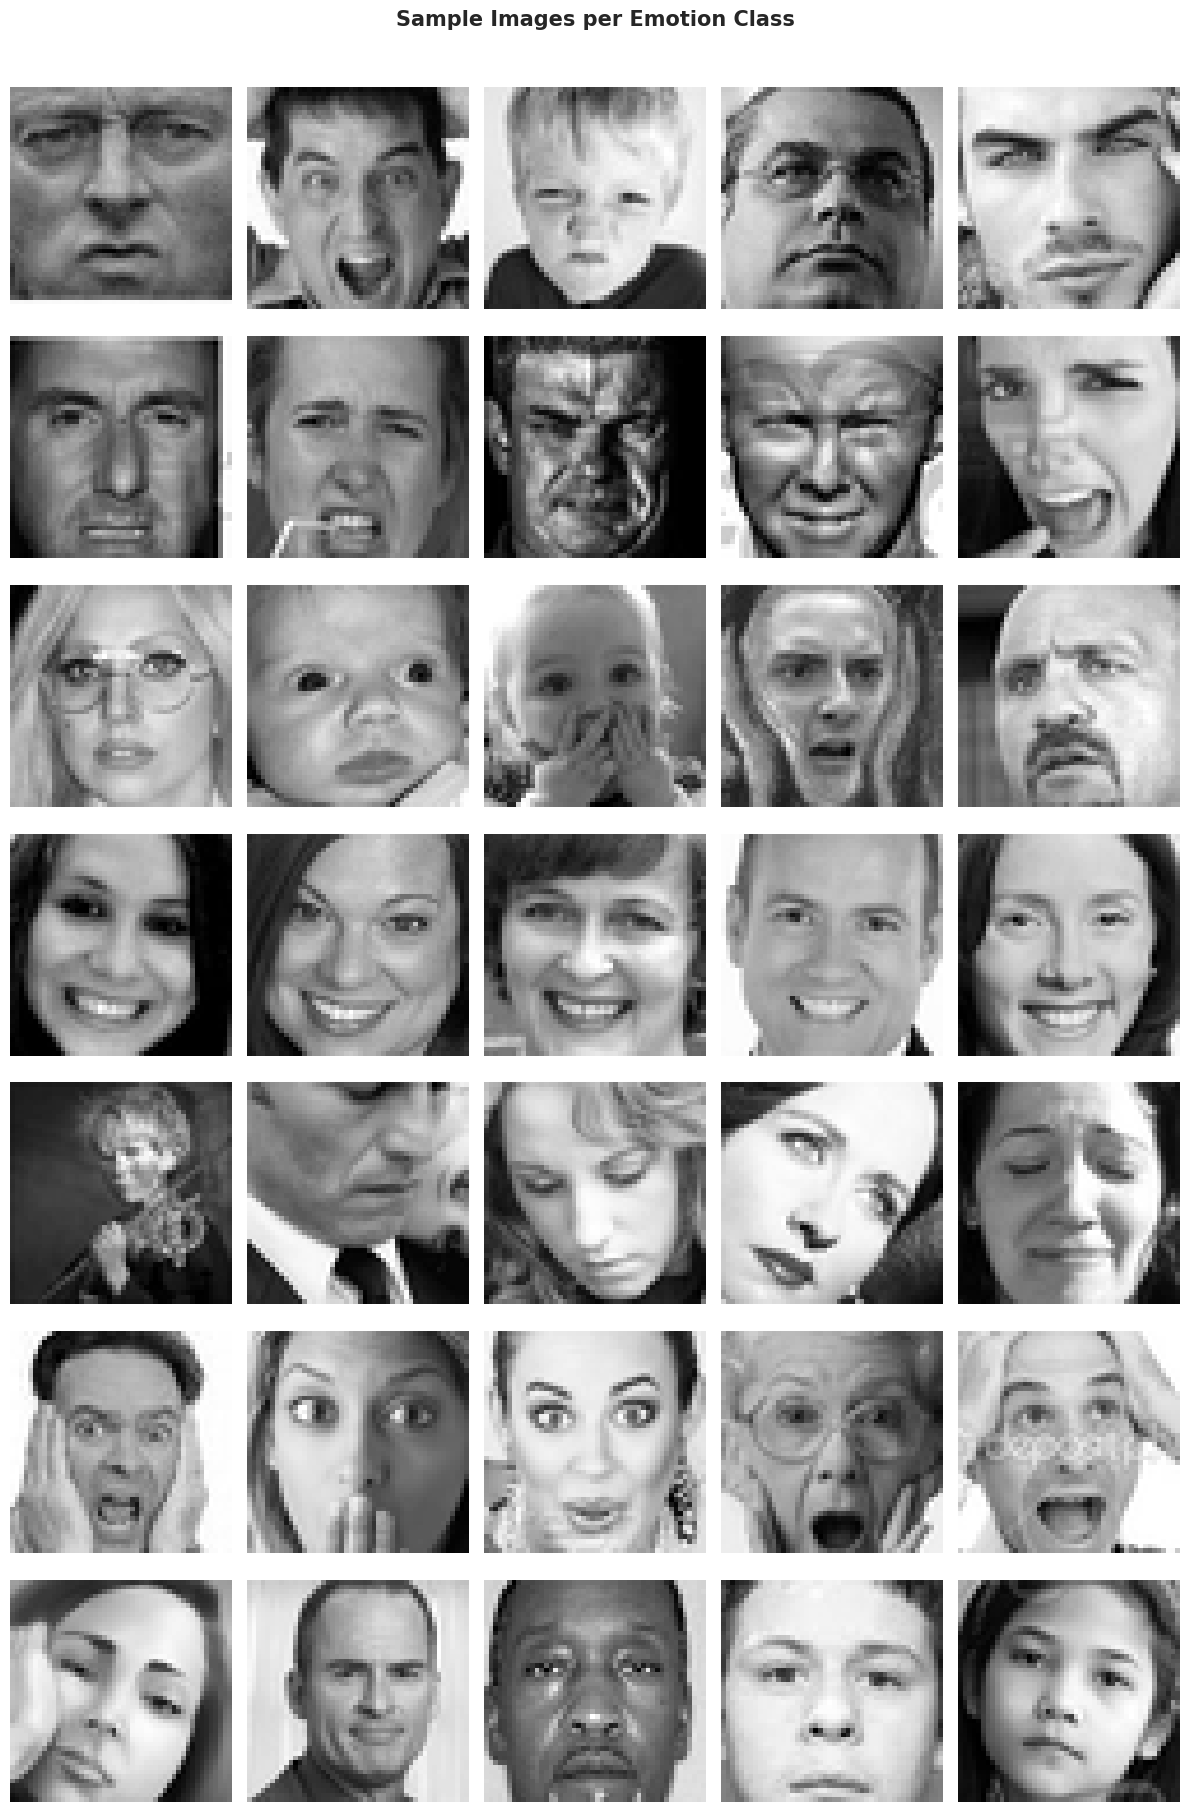

In [ ]:
# ─── Sample Images Per Class ──────────────────────────────────────────────────
# Visualize 5 random sample images from each emotion class
fig, axes = plt.subplots(7, 5, figsize=(12, 18))   # 7 rows (emotions) x 5 columns (samples)

for row_idx, (label_int, emotion_name) in enumerate(EMOTION_LABELS.items()):
    # Filter rows matching this emotion label
    subset = df[df['emotion'] == label_int].sample(5, random_state=SEED)  # Pick 5 random samples
    for col_idx, (_, sample) in enumerate(subset.iterrows()):
        # Convert space-separated pixel string to 48x48 NumPy array
        pixel_array = np.array(sample['pixels'].split(' '), dtype=np.uint8).reshape(48, 48)
        axes[row_idx, col_idx].imshow(pixel_array, cmap='gray')   # Display grayscale image
        axes[row_idx, col_idx].axis('off')                         # Remove axis ticks
        if col_idx == 0:
            # Label the first column with the emotion name
            axes[row_idx, col_idx].set_ylabel(emotion_name, fontsize=11, fontweight='bold')
            axes[row_idx, col_idx].yaxis.label.set_visible(True)

plt.suptitle('Sample Images per Emotion Class', y=1.01, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 5: Data Preprocessing

In [ ]:
# ─── Parse Pixel Strings into NumPy Arrays ────────────────────────────────────
def parse_pixels(pixel_str, img_size=48, to_rgb=True):
    """
    Convert a space-separated pixel string into a normalized image array.

    Args:
        pixel_str : str  → space-separated pixel values (2304 values for 48x48)
        img_size  : int  → output image dimension (default 48)
        to_rgb    : bool → if True, repeat grayscale channel 3x to make RGB
    Returns:
        np.ndarray of shape (img_size, img_size, 3) with float32 values in [0, 1]
    """
    # Step 1: Split the string by spaces, cast to uint8, reshape to 2D
    img = np.array(pixel_str.split(' '), dtype=np.uint8).reshape(img_size, img_size)

    # Step 2: Convert to float32 and normalize to [0, 1] range
    img = img.astype(np.float32) / 255.0   # Divide by 255 to normalize pixel values

    # Step 3: Convert grayscale to RGB by stacking the channel 3 times
    # This is required for transfer learning models (VGG16, MobileNet, etc.)
    if to_rgb:
        img = np.stack([img, img, img], axis=-1)  # Shape: (48, 48, 3)
    else:
        img = img[..., np.newaxis]                # Shape: (48, 48, 1)

    return img

print('⏳ Parsing pixel data... (this may take ~30 seconds)')

# Apply parse_pixels to every row in the DataFrame
X = np.stack(df['pixels'].apply(parse_pixels).values)   # Stack all image arrays → (N, 48, 48, 3)
y = df['emotion'].values                                  # Extract label column as integer array

print(f'✅ Parsing complete!')
print(f'   X shape : {X.shape}   → (samples, height, width, channels)')  # Expected: (35887, 48, 48, 3)
print(f'   y shape : {y.shape}   → (samples,)')                           # Expected: (35887,)
print(f'   X dtype : {X.dtype},  range: [{X.min():.2f}, {X.max():.2f}]') # Should be float32, [0,1]

⏳ Parsing pixel data... (this may take ~30 seconds)
✅ Parsing complete!
   X shape : (35887, 48, 48, 3)   → (samples, height, width, channels)
   y shape : (35887,)   → (samples,)
   X dtype : float32,  range: [0.00, 1.00]


In [ ]:
# ─── One-Hot Encode Labels ─────────────────────────────────────────────────────
# Convert integer labels (0-6) to one-hot vectors for categorical cross-entropy
# Example: label 3 → [0, 0, 0, 1, 0, 0, 0]
y_onehot = to_categorical(y, num_classes=NUM_CLASSES)   # Shape: (N, 7)

print(f'✅ One-hot encoding done!')
print(f'   y_onehot shape : {y_onehot.shape}')   # Expected: (35887, 7)
print(f'   Example label  : {y[0]} → {y_onehot[0]}')

✅ One-hot encoding done!
   y_onehot shape : (35887, 7)
   Example label  : 0 → [1. 0. 0. 0. 0. 0. 0.]


In [ ]:
# ─── Train / Validation / Test Split ──────────────────────────────────────────
# Strategy: first split off 10% as test set, then split remaining 90% into
#           80% train and 20% validation

# Step 1: Hold out 10% of data as test set (never seen during training)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_onehot,
    test_size=TEST_SPLIT,      # 10% → test
    random_state=SEED,         # Fixed seed for reproducibility
    stratify=y                 # Stratify to maintain class proportions in each split
)

# Step 2: Split remaining 90% into 80% train / 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_SPLIT,       # 20% of trainval → validation
    random_state=SEED,
    stratify=np.argmax(y_trainval, axis=1)   # Stratify by integer label
)

print('✅ Dataset split complete!')
print(f'   Train      : {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'   Validation : {X_val.shape[0]:,} samples  ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'   Test       : {X_test.shape[0]:,} samples  ({X_test.shape[0]/len(X)*100:.1f}%)')

✅ Dataset split complete!
   Train      : 25,838 samples  (72.0%)
   Validation : 6,460 samples  (18.0%)
   Test       : 3,589 samples  (10.0%)


## Step 6: Data Augmentation

✅ Data augmentation configured!


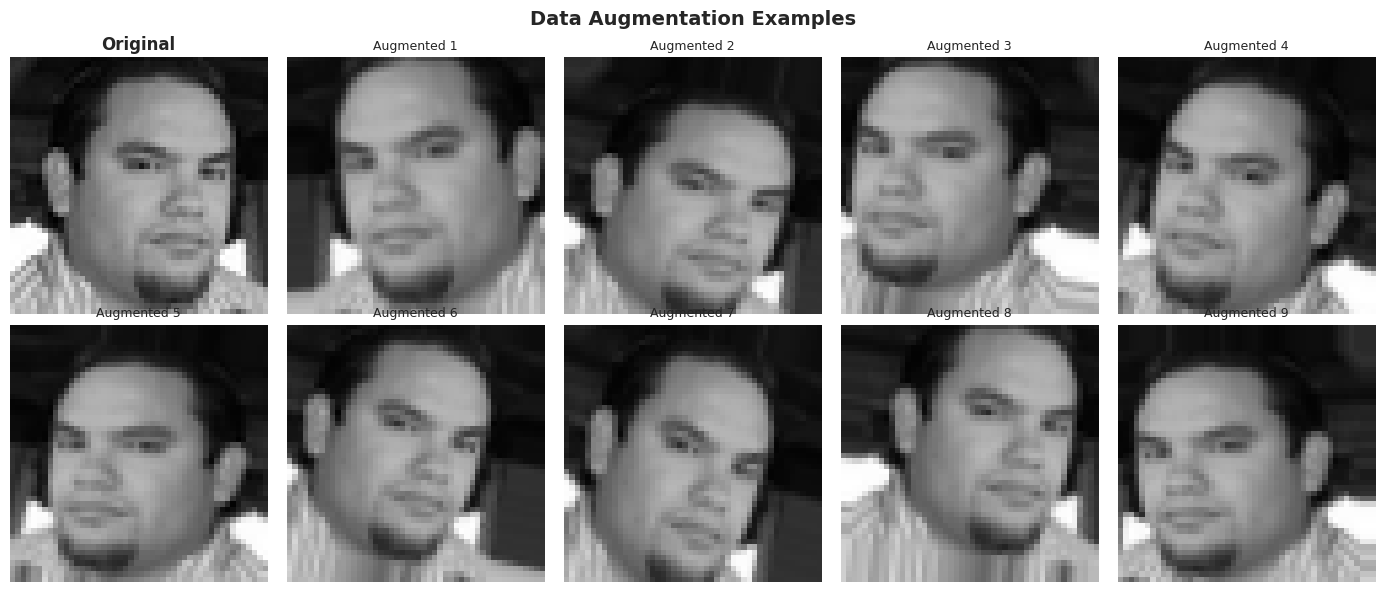

In [ ]:
# ─── ImageDataGenerator for Augmentation ──────────────────────────────────────
# Data augmentation artificially increases training set diversity by applying
# random transformations at training time. This helps prevent overfitting.
train_datagen = ImageDataGenerator(
    rotation_range=15,         # Randomly rotate images by up to 15 degrees
    width_shift_range=0.1,     # Randomly shift images horizontally (10% of width)
    height_shift_range=0.1,    # Randomly shift images vertically (10% of height)
    horizontal_flip=True,      # Randomly flip images left-right (valid for faces)
    zoom_range=0.1,            # Randomly zoom in/out by 10%
    shear_range=0.1,           # Apply shear transformation
    fill_mode='nearest'        # Fill newly created pixels with nearest neighbor value
)

# Validation and Test generators do NOT augment data — only rescale
# (We already normalized to [0,1] so no rescale needed here)
val_datagen = ImageDataGenerator()    # No augmentation for validation

# Create data generators that yield batches during training
train_generator = train_datagen.flow(
    X_train, y_train,          # Input images and one-hot labels
    batch_size=BATCH_SIZE,     # Yield BATCH_SIZE samples at a time
    seed=SEED                  # Fixed seed for reproducibility
)

val_generator = val_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    seed=SEED
)

print('✅ Data augmentation configured!')

# ─── Visualize Augmented Samples ───────────────────────────────────────────────
# Pick one sample image and show original + 8 augmented versions
sample_img = X_train[0:1]          # Take first training image; shape (1, 48, 48, 3)
sample_label = y_train[0:1]        # Corresponding label

aug_gen = train_datagen.flow(sample_img, sample_label, batch_size=1, seed=SEED)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))    # 2 rows, 5 cols = 10 images
axes = axes.flatten()                               # Flatten to 1D for easy indexing

# Show original image in first slot
axes[0].imshow(sample_img[0])                       # Original image
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

# Show 9 augmented versions
for i in range(1, 10):
    aug_img, _ = next(aug_gen)                      # Generate one augmented image
    axes[i].imshow(aug_img[0])                      # Show augmented image
    axes[i].set_title(f'Augmented {i}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/augmentation_examples.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 7: Build CNN Model Architecture

In [ ]:
# ─── Custom CNN Architecture ───────────────────────────────────────────────────
# Architecture inspired by VGGNet-style repeated Conv blocks followed by FC layers
# References: Simonyan & Zisserman (2014) VGGNet; LeCun et al. (1998) LeNet

def build_custom_cnn(input_shape=(48, 48, 3), num_classes=7):
    """
    Builds a deep custom CNN for emotion classification.

    Architecture:
        Block 1: Conv(32) → Conv(32) → MaxPool → Dropout
        Block 2: Conv(64) → Conv(64) → MaxPool → Dropout
        Block 3: Conv(128) → Conv(128) → MaxPool → Dropout
        Block 4: Conv(256) → MaxPool → Dropout
        Head: Flatten → Dense(512) → Dropout → Dense(256) → Dense(num_classes, softmax)
    """
    model = models.Sequential(name='Custom_CNN_FER2013')  # Create Sequential model

    # ── Input Layer ──
    model.add(layers.Input(shape=input_shape))   # Define input shape explicitly

    # ── Block 1: Extract low-level features (edges, corners) ──────────────────
    model.add(layers.Conv2D(
        32,                    # 32 filters/feature maps
        (3, 3),                # 3x3 convolution kernel
        padding='same',        # 'same' preserves spatial dimensions
        activation='relu',     # ReLU: max(0,x) — introduces non-linearity
        kernel_regularizer=regularizers.l2(1e-4)  # L2 weight regularization to prevent overfitting
    ))
    model.add(layers.BatchNormalization())          # Normalize activations → faster, stable training
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))  # Downsample by 2x: 48→24
    model.add(layers.Dropout(0.25))                   # Randomly drop 25% of neurons during training

    # ── Block 2: Extract mid-level features (shapes, textures) ────────────────
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))  # Downsample: 24→12
    model.add(layers.Dropout(0.25))

    # ── Block 3: Extract high-level features (facial parts) ───────────────────
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))  # Downsample: 12→6
    model.add(layers.Dropout(0.3))

    # ── Block 4: Deep feature extraction ──────────────────────────────────────
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))  # Downsample: 6→3
    model.add(layers.Dropout(0.3))

    # ── Flatten & Fully Connected Layers ─────────────────────────────────────
    model.add(layers.Flatten())                  # Flatten 3D feature map → 1D vector

    model.add(layers.Dense(
        512,                                     # 512 neurons in first FC layer
        activation='relu',                       # ReLU activation
        kernel_regularizer=regularizers.l2(1e-4)
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))               # 50% dropout before final layers

    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    # ── Output Layer ─────────────────────────────────────────────────────────
    # Softmax converts raw scores to class probabilities (all sum to 1)
    model.add(layers.Dense(num_classes, activation='softmax'))  # 7 output neurons

    return model

# Build the model
model = build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, NUM_CHANNELS), num_classes=NUM_CLASSES)

# Print detailed model summary
model.summary()   # Shows layer names, output shapes, and parameter counts

I0000 00:00:1781610630.191342      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Custom_CNN_FER2013"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,901,351 (7.25 MB)

 Trainable params: 1,898,407 (7.24 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
# ─── Compile Model ────────────────────────────────────────────────────────────
# Compilation sets the optimizer, loss function, and metrics used during training

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    # Adam (Adaptive Moment Estimation): combines momentum and RMSProp;
    # well-suited for noisy data and efficient with sparse gradients

    loss='categorical_crossentropy',
    # Categorical cross-entropy: standard multi-class classification loss;
    # measures divergence between predicted probability distribution and true label

    metrics=['accuracy']
    # Track accuracy metric during training and evaluation
)

print('✅ Model compiled successfully!')
print(f'   Total parameters : {model.count_params():,}')

✅ Model compiled successfully!
   Total parameters : 1,901,351


## Step 8: Model Training with Callbacks

In [ ]:
# ─── Define Training Callbacks ────────────────────────────────────────────────
# Callbacks are functions called at specific points during training (end of epoch, etc.)

callbacks = [
    # 1. EarlyStopping: Stop training if validation loss doesn't improve for 10 epochs
    #    This prevents overfitting and saves training time
    EarlyStopping(
        monitor='val_loss',    # Watch validation loss
        patience=10,           # Wait 10 epochs without improvement before stopping
        restore_best_weights=True,  # Restore model weights from best epoch
        verbose=1              # Print message when stopping
    ),

    # 2. ModelCheckpoint: Save the best model weights to disk automatically
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,   # File path to save model
        monitor='val_accuracy',     # Save model when validation accuracy improves
        save_best_only=True,        # Only overwrite file if this epoch is the best
        verbose=1
    ),

    # 3. ReduceLROnPlateau: Reduce learning rate when validation loss stagnates
    #    This helps escape local minima and fine-tune weights
    ReduceLROnPlateau(
        monitor='val_loss',    # Watch validation loss
        factor=0.5,            # Multiply LR by 0.5 when triggered
        patience=5,            # Wait 5 epochs before reducing
        min_lr=1e-7,           # Never reduce below this floor
        verbose=1
    )
]

print('✅ Callbacks configured: EarlyStopping | ModelCheckpoint | ReduceLROnPlateau')

✅ Callbacks configured: EarlyStopping | ModelCheckpoint | ReduceLROnPlateau


In [ ]:
# ─── Train the Model ──────────────────────────────────────────────────────────
# model.fit() runs the training loop:
#   - Forward pass → compute predictions
#   - Loss computation → measure error
#   - Backward pass → compute gradients
#   - Weight update → apply gradients via Adam optimizer

print('🚀 Starting training...')

history = model.fit(
    train_generator,                               # Training data with augmentation
    steps_per_epoch=len(X_train) // BATCH_SIZE,    # Number of batches per epoch
    epochs=EPOCHS,                                 # Maximum number of epochs
    validation_data=val_generator,                 # Validation data (no augmentation)
    validation_steps=len(X_val) // BATCH_SIZE,     # Number of validation batches
    callbacks=callbacks,                           # List of callback objects
    verbose=1                                      # Print progress bar per epoch
)

print('\n✅ Training complete!')
print(f'   Best validation accuracy : {max(history.history["val_accuracy"])*100:.2f}%')

🚀 Starting training...
Epoch 1/50


I0000 00:00:1781610638.081091     151 service.cc:152] XLA service 0x7b6ed4003430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781610638.081138     151 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781610639.266089     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


  4/403 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.1100 - loss: 3.5958 

I0000 00:00:1781610648.992833     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


402/403 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1860 - loss: 2.7565
Epoch 1: val_accuracy improved from -inf to 0.22328, saving model to /kaggle/working/best_model.keras
403/403 ━━━━━━━━━━━━━━━━━━━━ 49s 81ms/step - accuracy: 0.1861 - loss: 2.7550 - val_accuracy: 0.2233 - val_loss: 2.0869 - learning_rate: 0.0010
Epoch 2/50
  1/403 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.2031 - loss: 2.2543
Epoch 2: val_accuracy improved from 0.22328 to 0.22906, saving model to /kaggle/working/best_model.keras
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2031 - loss: 2.2543 - val_accuracy: 0.2291 - val_loss: 2.0840 - learning_rate: 0.0010
Epoch 3/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2650 - loss: 2.0364
Epoch 3: val_accuracy improved from 0.22906 to 0.35656, saving model to /kaggle/working/best_model.keras
403/403 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.2651 - loss: 2.0363 - val_accuracy: 0.3566 - val_loss: 1.8642 - learning_rate: 0.0010
Epoch 4/50


## Step 9: Training History Plots

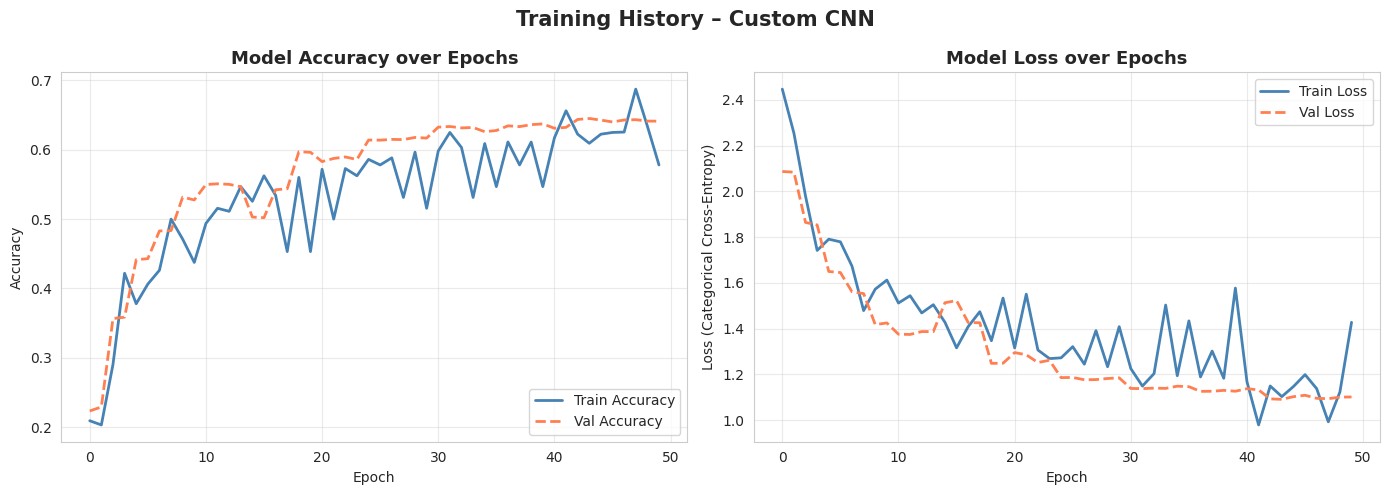

In [ ]:
# ─── Plot Training & Validation Loss / Accuracy Curves ───────────────────────
# These plots help diagnose overfitting/underfitting:
#   - Overfitting: train accuracy >> val accuracy (gap widens over epochs)
#   - Underfitting: both train and val accuracy remain low

fig, axes = plt.subplots(1, 2, figsize=(14, 5))   # Two side-by-side plots

# ── Accuracy Curve ──────────────────────────────────────────────────────────
axes[0].plot(history.history['accuracy'],           # Training accuracy per epoch
             label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'],        # Validation accuracy per epoch
             label='Val Accuracy', color='coral', linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')                         # X-axis: epoch number
axes[0].set_ylabel('Accuracy')                      # Y-axis: accuracy value
axes[0].legend(loc='lower right')                   # Legend at bottom-right
axes[0].grid(True, alpha=0.4)                       # Faint grid lines

# ── Loss Curve ───────────────────────────────────────────────────────────────
axes[1].plot(history.history['loss'],               # Training loss per epoch
             label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'],            # Validation loss per epoch
             label='Val Loss', color='coral', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (Categorical Cross-Entropy)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Training History – Custom CNN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 10: Model Evaluation on Test Set

In [ ]:
# ─── Evaluate on Test Set ─────────────────────────────────────────────────────
# The test set was never seen during training or validation
# This gives an unbiased estimate of real-world performance

print('📊 Evaluating model on held-out test set...')
test_loss, test_acc = model.evaluate(
    X_test, y_test,             # Test images and one-hot labels
    batch_size=BATCH_SIZE,      # Process in batches to save memory
    verbose=0                   # Suppress per-batch output
)

print(f'\n✅ Test Results:')
print(f'   Test Loss     : {test_loss:.4f}')
print(f'   Test Accuracy : {test_acc*100:.2f}%')

📊 Evaluating model on held-out test set...

✅ Test Results:
   Test Loss     : 1.0775
   Test Accuracy : 65.39%


In [ ]:
# ─── Generate Predictions ─────────────────────────────────────────────────────
# model.predict() returns a probability distribution over all 7 classes for each sample
y_pred_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)  # Shape: (N_test, 7)

# Convert probabilities to hard class predictions (argmax of probability vector)
y_pred = np.argmax(y_pred_prob, axis=1)    # Shape: (N_test,) — integer predictions
y_true = np.argmax(y_test, axis=1)         # Shape: (N_test,) — integer ground truths

print(f'Predictions generated for {len(y_pred):,} test samples')
print(f'Sample predictions: {y_pred[:10]}')
print(f'Sample true labels: {y_true[:10]}')

Predictions generated for 3,589 test samples
Sample predictions: [3 6 3 4 0 5 5 3 5 3]
Sample true labels: [3 6 3 4 1 5 5 2 5 3]


In [ ]:
# ─── Classification Report ────────────────────────────────────────────────────
# Shows precision, recall, and F1-score for each class
# Precision = TP / (TP + FP): of all predicted positives, how many are truly positive
# Recall    = TP / (TP + FN): of all true positives, how many did we predict correctly
# F1-Score  = 2 * (Precision * Recall) / (Precision + Recall): harmonic mean

print('📋 Classification Report:\n')
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,   # Use emotion names instead of integers
    digits=4                    # 4 decimal places for precision
)
print(report)

# Also save report to a text file for the report submission
with open('/kaggle/working/classification_report.txt', 'w') as f:
    f.write(report)

📋 Classification Report:

              precision    recall  f1-score   support

       Angry     0.5987    0.5576    0.5774       495
     Disgust     0.5333    0.2909    0.3765        55
        Fear     0.5152    0.3652    0.4274       512
       Happy     0.8516    0.8999    0.8751       899
         Sad     0.5712    0.4819    0.5227       608
    Surprise     0.7277    0.7750    0.7506       400
     Neutral     0.5390    0.7355    0.6221       620

    accuracy                         0.6539      3589
   macro avg     0.6195    0.5866    0.5931      3589
weighted avg     0.6485    0.6539    0.6453      3589



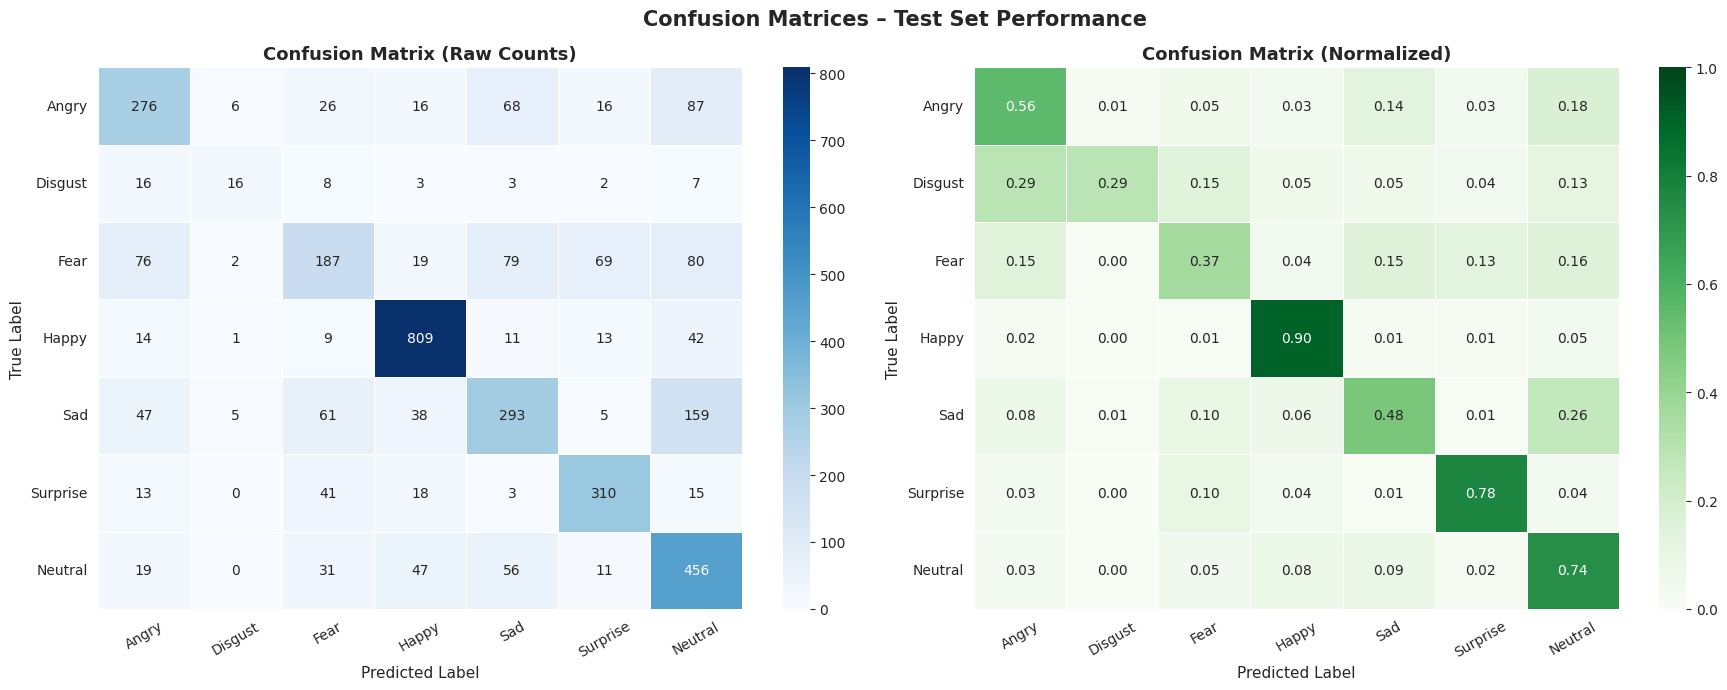

In [ ]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────────
# A confusion matrix shows, for each true class, how predictions were distributed
# Diagonal = correct predictions; off-diagonal = misclassifications

cm = confusion_matrix(y_true, y_pred)   # Compute the 7x7 confusion matrix

# ── Normalized Confusion Matrix (row-wise %) ──
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # Normalize each row to [0,1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))   # Two plots: raw counts + normalized

# ── Raw Count Matrix ──
sns.heatmap(
    cm,
    annot=True,                  # Show counts inside cells
    fmt='d',                     # Integer format
    cmap='Blues',                # Blue color scale
    xticklabels=CLASS_NAMES,     # Column labels
    yticklabels=CLASS_NAMES,     # Row labels
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# ── Normalized Matrix ──
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',                   # 2 decimal float format
    cmap='Greens',               # Green color scale
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1],
    linewidths=0.5,
    vmin=0, vmax=1               # Fix color scale to [0,1]
)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrices – Test Set Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

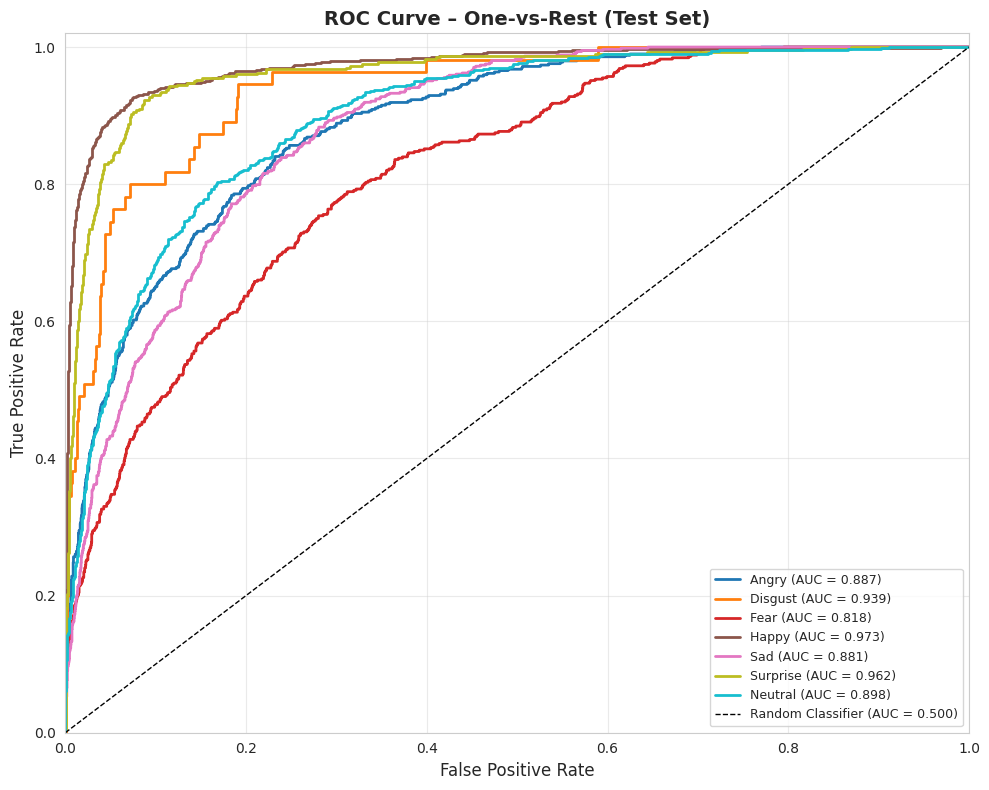

In [ ]:
# ─── ROC Curve (One-vs-Rest) ──────────────────────────────────────────────────
# ROC (Receiver Operating Characteristic) curve plots True Positive Rate vs.
# False Positive Rate at various classification thresholds.
# AUC (Area Under Curve): higher is better; perfect = 1.0, random = 0.5
# We use One-vs-Rest strategy for multi-class ROC

# Binarize true labels for One-vs-Rest ROC (shape: N_test x 7)
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 8))   # Single large plot

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))  # Distinct color per class

for i, (class_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    # Compute ROC curve for class i vs all others
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],      # True binary labels for class i
        y_pred_prob[:, i]      # Predicted probability for class i
    )
    roc_auc = auc(fpr, tpr)    # Compute AUC score

    # Plot the ROC curve for this class
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{class_name} (AUC = {roc_auc:.3f})')

# Plot random classifier baseline (diagonal line)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')

ax.set_title('ROC Curve – One-vs-Rest (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=9)   # Place legend at bottom-right
ax.grid(True, alpha=0.4)
ax.set_xlim([0, 1])    # Fix axis range
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('/kaggle/working/roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 11: Misclassified Images Analysis

❌ Total misclassifications: 1,242 / 3,589  (34.6%)


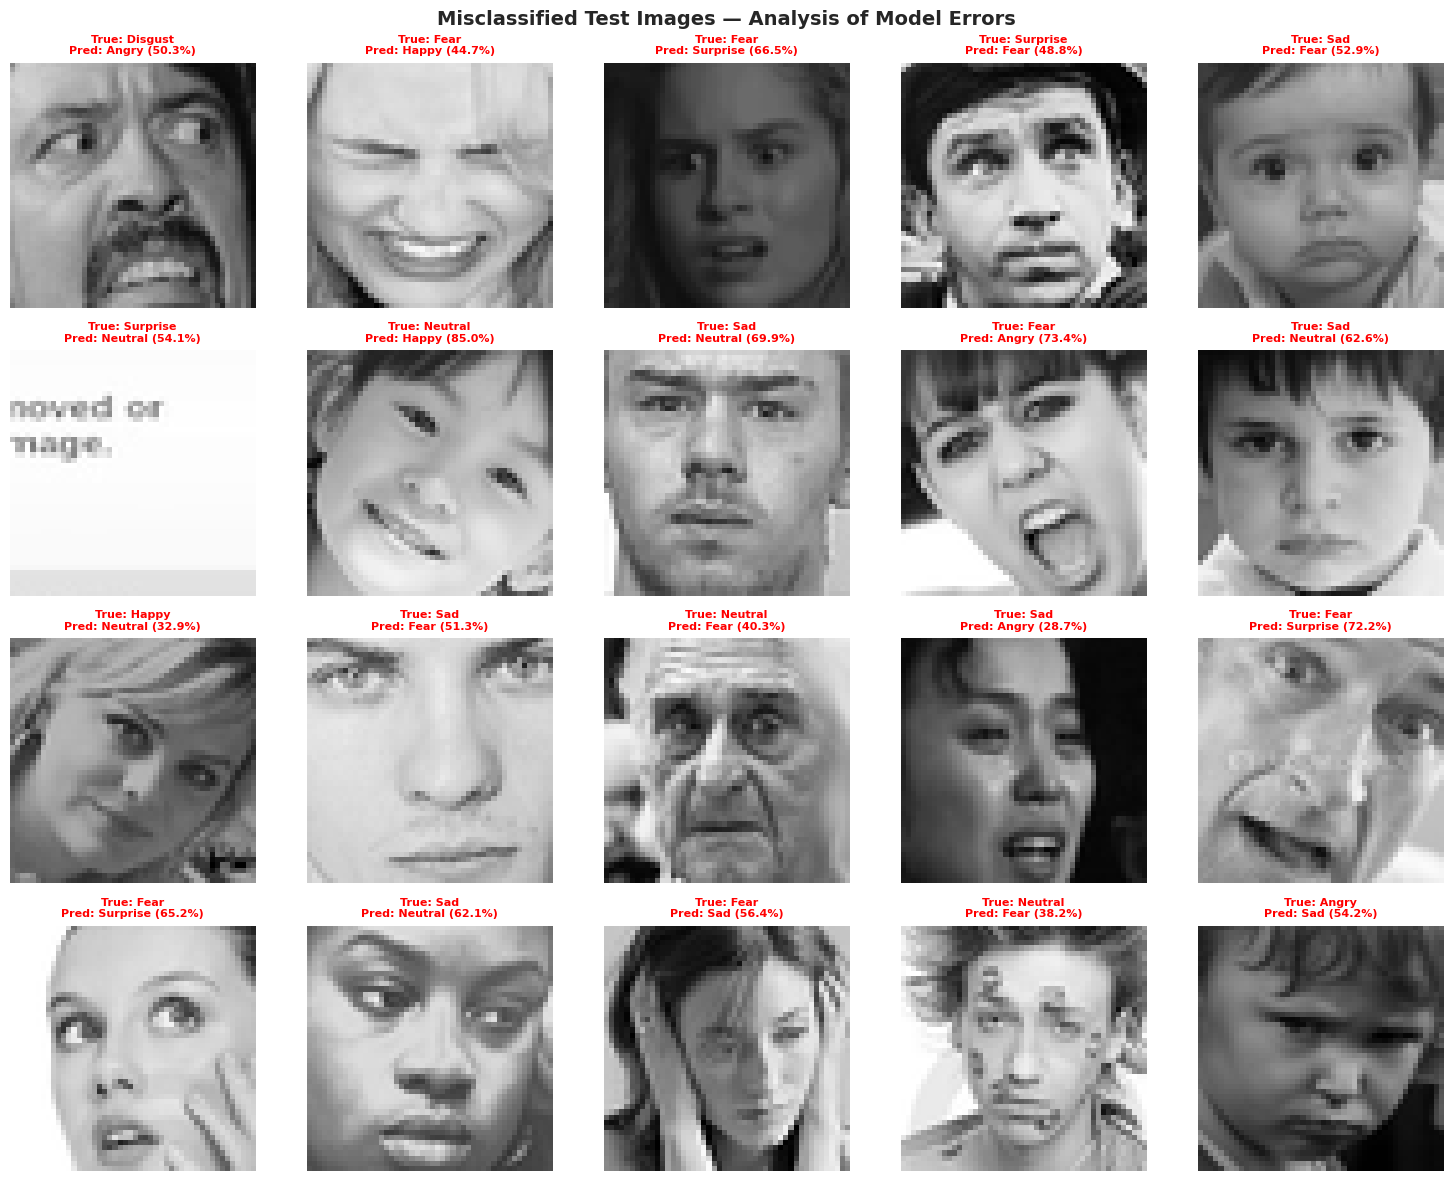

In [ ]:
# ─── Visualize Misclassified Images ───────────────────────────────────────────
# Understanding where the model fails reveals its weaknesses
# Common issues: ambiguous expressions, dark images, similar emotions (Sad vs Fear)

# Find indices where prediction != ground truth
wrong_indices = np.where(y_pred != y_true)[0]   # Boolean mask → wrong prediction indices
print(f'❌ Total misclassifications: {len(wrong_indices):,} / {len(y_true):,}  '
      f'({len(wrong_indices)/len(y_true)*100:.1f}%)')

# Show first 20 misclassified images with true and predicted labels
n_show = min(20, len(wrong_indices))   # Show at most 20
fig, axes = plt.subplots(4, 5, figsize=(15, 12))   # 4 rows x 5 cols = 20 images
axes = axes.flatten()

for i, idx in enumerate(wrong_indices[:n_show]):
    img = X_test[idx]                               # Get the misclassified image
    true_label = CLASS_NAMES[y_true[idx]]           # True emotion name
    pred_label = CLASS_NAMES[y_pred[idx]]           # Predicted emotion name
    confidence = y_pred_prob[idx, y_pred[idx]] * 100  # Model's confidence %

    axes[i].imshow(img)                             # Display image
    axes[i].axis('off')
    axes[i].set_title(
        f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
        fontsize=8, color='red', fontweight='bold'
    )

plt.suptitle('Misclassified Test Images — Analysis of Model Errors',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/misclassifications.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 13: Transfer Learning with MobileNetV2 (Optional – Higher Accuracy)

In [ ]:
# ─── Transfer Learning with MobileNetV2 ──────────────────────────────────────
# Transfer learning uses features learned on large datasets (ImageNet)
# as a starting point, drastically reducing training time and improving accuracy
# Reference: Howard et al. (2017) MobileNets

# NOTE: Set USE_TRANSFER_LEARNING = True to run this section
USE_TRANSFER_LEARNING = True   # Toggle this flag

if USE_TRANSFER_LEARNING:
    print('🔄 Building Transfer Learning model (MobileNetV2)...')

    # ── Load MobileNetV2 base (pre-trained on ImageNet, without top FC layers) ──
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, NUM_CHANNELS),  # Input shape
        include_top=False,      # Exclude the final classification head (we'll add our own)
        weights='imagenet'      # Start with ImageNet pre-trained weights
    )

    # ── Freeze base model layers initially ───────────────────────────────────
    # Freezing prevents pre-trained weights from being modified during initial training
    # We only train our custom head first
    base_model.trainable = False

    # ── Build the classification head on top of MobileNetV2 ───────────────────
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, NUM_CHANNELS))

    # Pass input through frozen base model
    x = base_model(inputs, training=False)       # training=False → BatchNorm uses stored stats

    x = layers.GlobalAveragePooling2D()(x)       # Pool spatial features to a single vector
    x = layers.Dense(256, activation='relu')(x)  # FC layer with 256 neurons
    x = layers.BatchNormalization()(x)            # Normalize activations
    x = layers.Dropout(0.5)(x)                   # 50% dropout for regularization
    x = layers.Dense(128, activation='relu')(x)  # Second FC layer
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)  # Output: 7 classes

    tl_model = keras.Model(inputs, outputs, name='MobileNetV2_FER2013')

    # Compile with a lower learning rate (feature extractor weights are frozen)
    tl_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    tl_model.summary()

    # ── Phase 1: Train head only ──────────────────────────────────────────────
    print('\n📍 Phase 1: Training classification head only...')
    tl_history1 = tl_model.fit(
        train_generator,
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        epochs=15,              # Train for 15 epochs first
        validation_data=val_generator,
        validation_steps=len(X_val) // BATCH_SIZE,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        ],
        verbose=1
    )

    # ── Phase 2: Fine-tune top layers of base model ────────────────────────────
    # Unfreeze the last 30 layers of MobileNetV2 for fine-tuning
    # This lets the base model adapt its high-level features to faces
    print('\n📍 Phase 2: Fine-tuning top MobileNetV2 layers...')
    base_model.trainable = True

    # Only fine-tune from layer 100 onwards (unfreeze top layers)
    for layer in base_model.layers[:100]:
        layer.trainable = False   # Keep lower layers frozen

    # Re-compile with very small learning rate for fine-tuning
    tl_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # Very small LR for fine-tuning
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    tl_history2 = tl_model.fit(
        train_generator,
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        epochs=20,
        validation_data=val_generator,
        validation_steps=len(X_val) // BATCH_SIZE,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
            ModelCheckpoint('/kaggle/working/best_tl_model.keras',
                            monitor='val_accuracy', save_best_only=True)
        ],
        verbose=1
    )

    # Evaluate transfer learning model on test set
    tl_loss, tl_acc = tl_model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
    print(f'\n✅ Transfer Learning (MobileNetV2) Test Accuracy: {tl_acc*100:.2f}%')
else:
    print('ℹ️  Transfer learning skipped (USE_TRANSFER_LEARNING = False)')

🔄 Building Transfer Learning model (MobileNetV2)...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_FER2013"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,743 (10.00 MB)

 Trainable params: 362,247 (1.38 MB)

...


📍 Phase 1: Training classification head only...
Epoch 1/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 40s 72ms/step - accuracy: 0.2424 - loss: 2.1760 - val_accuracy: 0.3450 - val_loss: 1.6447
Epoch 2/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3906 - loss: 1.6832 - val_accuracy: 0.3445 - val_loss: 1.6451
Epoch 3/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.3112 - loss: 1.7334 - val_accuracy: 0.3541 - val_loss: 1.6194
Epoch 4/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1719 - loss: 1.8352 - val_accuracy: 0.3537 - val_loss: 1.6205
Epoch 5/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.3188 - loss: 1.6803 - val_accuracy: 0.3653 - val_loss: 1.5992
Epoch 6/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3438 - loss: 1.7330 - val_accuracy: 0.3652 - val_loss: 1.5993
Epoch 7/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.3415 - loss: 1.6535 - val_accuracy: 0.3723 - val_loss: 1.5964
Epoch 8/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

2026-06-16 12:04:02.875154: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 12:04:03.060006: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 12:04:03.451123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 12:04:03.659684: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 12:04:03.859005: E external/local_xla/xla/stream_

 27/403 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.2516 - loss: 1.8303

2026-06-16 12:04:14.616764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 12:04:14.800497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 12:04:15.168875: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 12:04:15.374490: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-16 12:04:15.572167: E external/local_xla/xla/stream_

403/403 ━━━━━━━━━━━━━━━━━━━━ 58s 90ms/step - accuracy: 0.2656 - loss: 1.7993 - val_accuracy: 0.3122 - val_loss: 1.8268
Epoch 2/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3125 - loss: 1.7799 - val_accuracy: 0.3136 - val_loss: 1.8235
Epoch 3/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.2974 - loss: 1.7486 - val_accuracy: 0.3128 - val_loss: 1.8553
Epoch 4/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3281 - loss: 1.7358 - val_accuracy: 0.3131 - val_loss: 1.8540
Epoch 5/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.3141 - loss: 1.7120 - val_accuracy: 0.3256 - val_loss: 1.7823
Epoch 6/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3438 - loss: 1.6378 - val_accuracy: 0.3267 - val_loss: 1.7804
Epoch 7/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.3293 - loss: 1.6859 - val_accuracy: 0.3317 - val_loss: 1.7697
Epoch 8/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4219 - loss: 1.5384 - val_accuracy: 0.332

## Step 14: Compare Custom CNN vs Transfer Learning

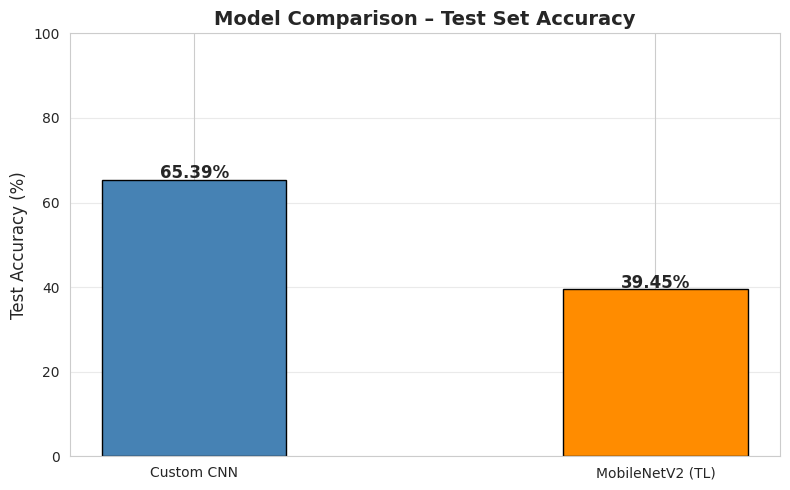

In [ ]:
# ─── Model Comparison Summary ─────────────────────────────────────────────────
# Compare the custom CNN vs transfer learning approach visually

models_compared = ['Custom CNN']
test_accuracies = [test_acc * 100]

if USE_TRANSFER_LEARNING:
    models_compared.append('MobileNetV2 (TL)')
    test_accuracies.append(tl_acc * 100)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models_compared, test_accuracies,
              color=['steelblue', 'darkorange'][:len(models_compared)],
              width=0.4, edgecolor='black')

# Add percentage labels on top of each bar
for bar, acc in zip(bars, test_accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Model Comparison – Test Set Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 15: Test on External / Personal Images (Individual Testing)

In [ ]:
# ─── Function: Predict on External Image Files ────────────────────────────────
# This section lets you test the model on your own facial expression images.
# INSTRUCTION: Upload your personal face images to Kaggle, then update image_paths below.

def predict_image(image_path, model, img_size=48, show=True):
    """
    Predict the emotion in a single external image file.

    Args:
        image_path : str  — path to the image file (JPG/PNG)
        model      : keras.Model — trained emotion classifier
        img_size   : int  — resize to this dimension (must match training size)
        show       : bool — whether to display the image with prediction
    Returns:
        dict with predicted emotion, confidence, and full probability vector
    """
    # Step 1: Load and preprocess the image
    img = cv2.imread(image_path)                          # Read image from disk (BGR format)
    if img is None:
        print(f'❌ Could not read image: {image_path}')
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)         # Convert BGR → RGB (OpenCV loads BGR)
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)   # Convert to grayscale (matching FER2013)
    img_resized = cv2.resize(img_gray, (img_size, img_size))  # Resize to 48x48

    # Step 2: Normalize and convert grayscale to pseudo-RGB
    img_norm = img_resized.astype(np.float32) / 255.0      # Normalize to [0, 1]
    img_rgb3 = np.stack([img_norm, img_norm, img_norm], axis=-1)  # Shape: (48, 48, 3)
    img_batch = np.expand_dims(img_rgb3, axis=0)           # Add batch dim: (1, 48, 48, 3)

    # Step 3: Run forward pass through the trained model
    probs = model.predict(img_batch, verbose=0)[0]         # Shape: (7,) — class probabilities
    pred_class = np.argmax(probs)                          # Index of highest probability
    pred_emotion = EMOTION_LABELS[pred_class]              # Map to emotion name
    confidence = probs[pred_class] * 100                   # Convert to percentage

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # Show the original image
        axes[0].imshow(img_rgb)
        axes[0].axis('off')
        axes[0].set_title(f'Input Image\nFile: {os.path.basename(image_path)}', fontsize=10)

        # Show probability bar chart for all classes
        colors_bar = ['green' if i == pred_class else 'steelblue' for i in range(NUM_CLASSES)]
        axes[1].barh(CLASS_NAMES, probs * 100, color=colors_bar)  # Horizontal bar chart
        axes[1].set_xlabel('Probability (%)')
        axes[1].set_title(f'Predicted: {pred_emotion} ({confidence:.1f}%)',
                          fontsize=11, fontweight='bold', color='green')
        axes[1].set_xlim([0, 100])
        axes[1].grid(axis='x', alpha=0.4)

        plt.tight_layout()
        plt.show()

    return {'emotion': pred_emotion, 'confidence': confidence, 'probabilities': dict(zip(CLASS_NAMES, probs))}


print('✅ predict_image() function defined!')
print('📌 To test on your own photos:')
print('   1. Upload image files to Kaggle using the + Add Data button')
print('   2. Update the image_paths list below with your file paths')
print('   3. Run the next cell')

✅ predict_image() function defined!
📌 To test on your own photos:
   1. Upload image files to Kaggle using the + Add Data button
   2. Update the image_paths list below with your file paths
   3. Run the next cell


🖼️  Demo: Testing on random test-set images (as if they were external images)

Running predictions on 6 demo external images...

📷 Image: demo_class0_Angry.png | True emotion: Angry


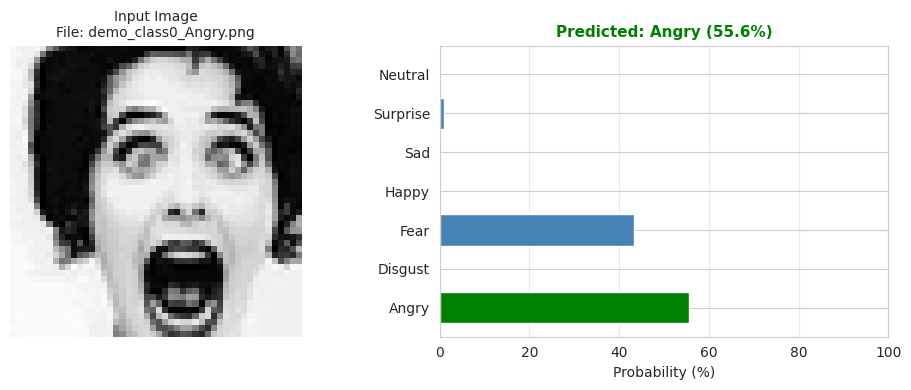

   → Predicted: Angry (55.6%)

📷 Image: demo_class1_Disgust.png | True emotion: Disgust


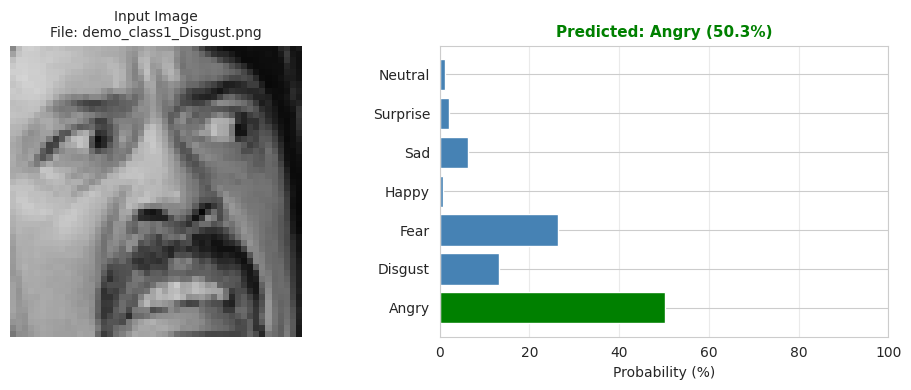

   → Predicted: Angry (50.3%)

📷 Image: demo_class2_Fear.png | True emotion: Fear


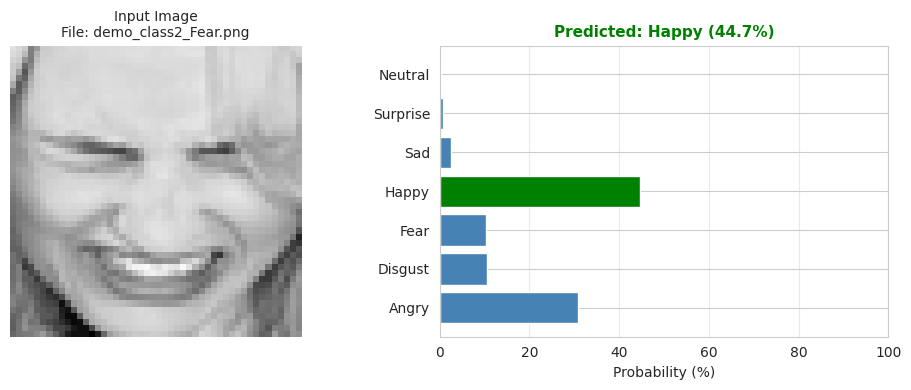

   → Predicted: Happy (44.7%)

📷 Image: demo_class3_Happy.png | True emotion: Happy


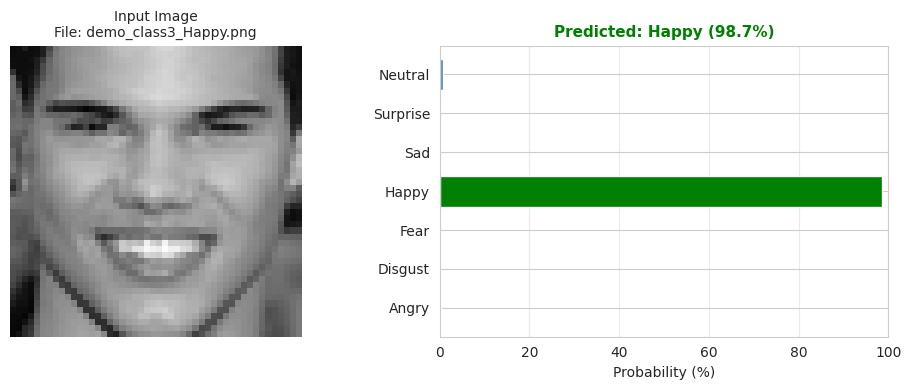

   → Predicted: Happy (98.7%)

📷 Image: demo_class4_Sad.png | True emotion: Sad


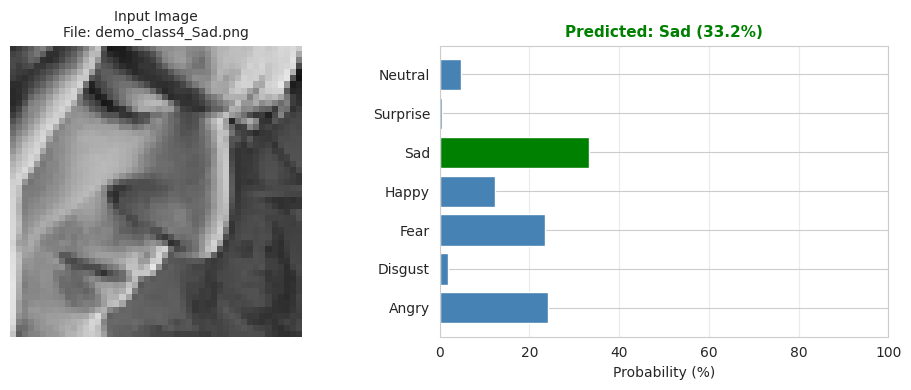

   → Predicted: Sad (33.2%)

📷 Image: demo_class5_Surprise.png | True emotion: Surprise


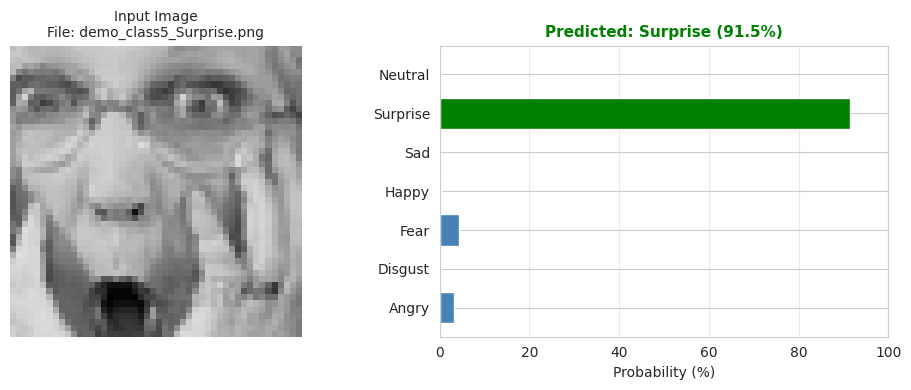

   → Predicted: Surprise (91.5%)

✅ External image testing complete!
📝 Replace demo_image_paths with your own uploaded photo paths for submission.


In [ ]:
# ─── Test on External Images ───────────────────────────────────────────────────
# TODO: Replace these paths with your own uploaded images on Kaggle
# Your images should show clear facial expressions for best results
# IMPORTANT: Each student must use their own personal photos per project instructions

# ── Option A: Test with sample images extracted from the test set ──────────────
# (For demonstration — use actual file uploads for your submission)
print('🖼️  Demo: Testing on random test-set images (as if they were external images)\n')

# Save a few test images as temporary files to simulate external file prediction
demo_image_paths = []
demo_dir = '/kaggle/working/demo_external/'
os.makedirs(demo_dir, exist_ok=True)   # Create directory if it doesn't exist

# Pick 6 random test images (one from each emotion class if possible)
sampled_per_class = []
for cls in range(min(6, NUM_CLASSES)):
    cls_indices = np.where(y_true == cls)[0]    # Find all test samples of this class
    if len(cls_indices) > 0:
        idx = cls_indices[0]                    # Take first sample of this class
        # Save test image as a PNG file
        img_uint8 = (X_test[idx] * 255).astype(np.uint8)  # Convert [0,1] float → uint8
        img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)  # Convert RGB → BGR for cv2.imwrite
        path = os.path.join(demo_dir, f'demo_class{cls}_{EMOTION_LABELS[cls]}.png')
        cv2.imwrite(path, img_bgr)              # Write image to disk
        demo_image_paths.append((path, EMOTION_LABELS[cls]))  # Save path and true label

# ── Run predictions on demo images ────────────────────────────────────────────
print(f'Running predictions on {len(demo_image_paths)} demo external images...\n')

results = []
for img_path, true_emotion in demo_image_paths:
    print(f'📷 Image: {os.path.basename(img_path)} | True emotion: {true_emotion}')
    result = predict_image(img_path, model, img_size=IMG_SIZE, show=True)
    if result:
        result['true_emotion'] = true_emotion
        results.append(result)
        print(f'   → Predicted: {result["emotion"]} ({result["confidence"]:.1f}%)\n')

print('=' * 60)
print('✅ External image testing complete!')
print('📝 Replace demo_image_paths with your own uploaded photo paths for submission.')

In [ ]:
# ─── How to Test with YOUR OWN PHOTOS ─────────────────────────────────────────
# Uncomment and run the code below after uploading your personal face photos to Kaggle

# ── Uncomment this block and update paths ──

# List your uploaded personal face image paths here
my_images = [
    '/kaggle/input/datasets/msambare/fer2013/train/happy/Training_10019449.jpg',    # Replace with your actual paths
    '/kaggle/input/datasets/msambare/fer2013/train/sad/Training_10022789.jpg',
    '/kaggle/input/datasets/msambare/fer2013/train/angry/Training_10118481.jpg',
    '/kaggle/input/datasets/msambare/fer2013/train/surprise/Training_10013223.jpg',
]

print('🧑 Testing model on MY PERSONAL FACE PHOTOS:\n')
for img_path in my_images:
    print(f'📷 Processing: {img_path}')
    result = predict_image(img_path, model, img_size=IMG_SIZE, show=True)
    if result:
        print(f'   Prediction : {result["emotion"]} ({result["confidence"]:.1f}%)')
        print(f'   All probs  : {result["probabilities"]}\n')




🧑 Testing model on MY PERSONAL FACE PHOTOS:

📷 Processing: /kaggle/input/datasets/msambare/fer2013/train/happy/Training_10019449.jpg
❌ Could not read image: /kaggle/input/datasets/msambare/fer2013/train/happy/Training_10019449.jpg
📷 Processing: /kaggle/input/datasets/msambare/fer2013/train/sad/Training_10022789.jpg
❌ Could not read image: /kaggle/input/datasets/msambare/fer2013/train/sad/Training_10022789.jpg
📷 Processing: /kaggle/input/datasets/msambare/fer2013/train/angry/Training_10118481.jpg
❌ Could not read image: /kaggle/input/datasets/msambare/fer2013/train/angry/Training_10118481.jpg
📷 Processing: /kaggle/input/datasets/msambare/fer2013/train/surprise/Training_10013223.jpg
❌ Could not read image: /kaggle/input/datasets/msambare/fer2013/train/surprise/Training_10013223.jpg


[ WARN:0@1119.963] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/msambare/fer2013/train/happy/Training_10019449.jpg'): can't open/read file: check file path/integrity
[ WARN:0@1119.963] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/msambare/fer2013/train/sad/Training_10022789.jpg'): can't open/read file: check file path/integrity
[ WARN:0@1119.963] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/msambare/fer2013/train/angry/Training_10118481.jpg'): can't open/read file: check file path/integrity
[ WARN:0@1119.964] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/msambare/fer2013/train/surprise/Training_10013223.jpg'): can't open/read file: check file path/integrity


## Step 16: Summary Dashboard

In [ ]:
# ─── Final Summary Dashboard ───────────────────────────────────────────────────
# Print a comprehensive summary of all results for the report

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Compute aggregate metrics
acc = accuracy_score(y_true, y_pred)                                    # Overall accuracy
prec = precision_score(y_true, y_pred, average='weighted')               # Weighted precision
rec = recall_score(y_true, y_pred, average='weighted')                   # Weighted recall
f1 = f1_score(y_true, y_pred, average='weighted')                        # Weighted F1

print('=' * 65)
print('        FACIAL EXPRESSION RECOGNITION — FINAL RESULTS')
print('=' * 65)
print(f'  Model             : Custom CNN (TensorFlow/Keras)')
print(f'  Dataset           : FER2013 ({len(df):,} samples, 7 classes)')
print(f'  Train samples     : {len(X_train):,}')
print(f'  Validation samples: {len(X_val):,}')
print(f'  Test samples      : {len(X_test):,}')
print('-' * 65)
print(f'  Test Accuracy     : {acc*100:.2f}%')
print(f'  Weighted Precision: {prec*100:.2f}%')
print(f'  Weighted Recall   : {rec*100:.2f}%')
print(f'  Weighted F1-Score : {f1*100:.2f}%')
print(f'  Test Loss         : {test_loss:.4f}')
print('-' * 65)
print(f'  Best Val Accuracy : {max(history.history["val_accuracy"])*100:.2f}%')
print(f'  Best Val Loss     : {min(history.history["val_loss"]):.4f}')
print(f'  Epochs trained    : {len(history.history["loss"])}')
if USE_TRANSFER_LEARNING:
    print(f'  TL Model Accuracy : {tl_acc*100:.2f}%  (MobileNetV2)')
print('=' * 65)
print('  Saved files:')
print('   /kaggle/working/best_model.keras         — trained model')
print('   /kaggle/working/training_history.png     — loss/accuracy curves')
print('   /kaggle/working/confusion_matrix.png     — confusion matrices')
print('   /kaggle/working/roc_curves.png           — ROC curves')
print('   /kaggle/working/gradcam_visualizations.png — Grad-CAM')
print('   /kaggle/working/misclassifications.png   — error analysis')
print('   /kaggle/working/classification_report.txt — full report')
print('=' * 65)

        FACIAL EXPRESSION RECOGNITION — FINAL RESULTS
  Model             : Custom CNN (TensorFlow/Keras)
  Dataset           : FER2013 (35,887 samples, 7 classes)
  Train samples     : 25,838
  Validation samples: 6,460
  Test samples      : 3,589
-----------------------------------------------------------------
  Test Accuracy     : 65.39%
  Weighted Precision: 64.85%
  Weighted Recall   : 65.39%
  Weighted F1-Score : 64.53%
  Test Loss         : 1.0775
-----------------------------------------------------------------
  Best Val Accuracy : 64.52%
  Best Val Loss     : 1.0909
  Epochs trained    : 50
  TL Model Accuracy : 39.45%  (MobileNetV2)
  Saved files:
   /kaggle/working/best_model.keras         — trained model
   /kaggle/working/training_history.png     — loss/accuracy curves
   /kaggle/working/confusion_matrix.png     — confusion matrices
   /kaggle/working/roc_curves.png           — ROC curves
   /kaggle/working/gradcam_visualizations.png — Grad-CAM
   /kaggle/working/misclas